<a href="https://colab.research.google.com/github/OlenaBogoliubova/DATA-LOVE-ACADEMY/blob/main/HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2_Bogoliubova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [ ]:
import pandas as pd
from google.colab import drive
import sys
import os
from process_bank_churn import preprocess_data

drive.mount('/content/drive')
bank_df = pd.read_csv("drive/MyDrive/DATA LOVE/train.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X_train, train_targets, X_val, val_targets, input_cols, scaler, encoder = \
    preprocess_data(bank_df, scale_numeric_features=False)

X = pd.concat([X_train, X_val])
y = pd.concat([train_targets, val_targets])

print(f"X shape: {X.shape}")

X shape: (15000, 13)


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

# kNN
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

# AUROC
train_auc = roc_auc_score(train_targets, knn.predict_proba(X_train)[:, 1])
val_auc   = roc_auc_score(val_targets,   knn.predict_proba(X_val)[:, 1])

print(f"AUROC Train: {train_auc:.4f}")
print(f"AUROC Val:   {val_auc:.4f}")
print(f"Gap:         {train_auc - val_auc:.4f}")

AUROC Train: 0.8238
AUROC Val:   0.5734
Gap:         0.2504


Висновок:

Gap 0.25 дуже великий, отже, модель сильно перенавчилася.
AUROC Val 0.57 це майже як випадкове вгадування (0.5), модель погана.
Це типова поведінка kNN, коли він просто запам'ятовує тренувальні точки і погано узагальнює на нових даних

kNN чутливий до масштабу ознак, а дані немасштабовані.

In [ ]:
X_train_scaled, train_targets, X_val_scaled, val_targets, input_cols, scaler, encoder = \
    preprocess_data(bank_df, scale_numeric_features=True)

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, train_targets)

train_auc = roc_auc_score(train_targets, knn.predict_proba(X_train_scaled)[:, 1])
val_auc   = roc_auc_score(val_targets,   knn.predict_proba(X_val_scaled)[:, 1])

print(f"AUROC Train: {train_auc:.4f}")
print(f"AUROC Val:   {val_auc:.4f}")

AUROC Train: 0.9559
AUROC Val:   0.8526


Після масштабування даних результат кращий.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': list(range(1, 51))}

# GridSearchCV
knn = KNeighborsClassifier()
grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, train_targets)

print(f"The best n_neighbors: {grid_search.best_params_['n_neighbors']}")
print(f"The best AUROC (CV): {grid_search.best_score_:.4f}")

# Best model
knn_best = grid_search.best_estimator_

# AUROC train \ val
train_auc = roc_auc_score(train_targets, knn_best.predict_proba(X_train_scaled)[:, 1])
val_auc   = roc_auc_score(val_targets,   knn_best.predict_proba(X_val_scaled)[:, 1])

print(f"\nAUROC Train: {train_auc:.4f}")
print(f"AUROC Val:   {val_auc:.4f}")
print(f"Gap:         {train_auc - val_auc:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
The best n_neighbors: 19
The best AUROC (CV): 0.8853

AUROC Train: 0.9227
AUROC Val:   0.8908
Gap:         0.0319


Висновок:

GridSearchCV знайшов оптимальне n_neighbors=19 — більше сусідів зменшило перенавчання.
Gap зменшився з 0.10 до 0.03, тобто модель стала значно стабільнішою,
Val AUROC виріс з 0.8526 до 0.8908 - це суттєве покращення.

Таким чином kNN з підібраним n_neighbors=19 — хороша модель без перенавчання.

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [ ]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
import numpy as np

param_grid = {
    'max_depth':      list(range(1, 21, 2)),  # 1, 3, 5, 7, ... 19
    'max_leaf_nodes': list(range(2, 11, 1))   # 2, 3, 4, ... 10
}

# GridSearchCV
dt = DecisionTreeClassifier(random_state=42)
grid_search_dt = GridSearchCV(
    dt,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_search_dt.fit(X_train, train_targets)
end = time.time()

print(f"Time Search: {end - start:.2f} sek")
print(f"Best parameters: {grid_search_dt.best_params_}")
print(f"Best AUROC (CV): {grid_search_dt.best_score_:.4f}")

dt_best = grid_search_dt.best_estimator_

# AUROC train \ val
train_auc = roc_auc_score(train_targets, dt_best.predict_proba(X_train)[:, 1])
val_auc   = roc_auc_score(val_targets,   dt_best.predict_proba(X_val)[:, 1])

print(f"\nAUROC Train: {train_auc:.4f}")
print(f"AUROC Val:   {val_auc:.4f}")
print(f"Gap:         {train_auc - val_auc:.4f}")

Fitting 3 folds for each of 90 candidates, totalling 270 fits
Time Search: 7.51 sek
Best parameters: {'max_depth': 5, 'max_leaf_nodes': 10}
Best AUROC (CV): 0.9014

AUROC Train: 0.9015
AUROC Val:   0.9002
Gap:         0.0013


Висновок:

GridSearchCV знайшов max_depth=5, max_leaf_nodes=10 — дерево невелике, але стабільне.
Gap лише 0.0013 — майже нульове перенавчання, найкраща генералізація з усіх моделей.
Val AUROC 0.9002 — трохи нижчий ніж вручну підібране дерево (~0.92).

Ручний підбір дав вищий Val AUROC (~0.92), але більший gap.
GridSearchCV оптимізував саме крос-валідаційний AUROC, тому знайшов більш стабільну але трохи менш точну модель, тому що GridSearchCV мінімізує перенавчання та може давати трохи нижчий результат на конкретному val, але краще узагальнює на нових даних

Час пошуку: лише 7.5 секунд для 270 моделей — це швидко.

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [ ]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import time

# RandomizedSearchCV
dt = DecisionTreeClassifier(random_state=42)
random_search_dt = RandomizedSearchCV(
    dt,
    params_dt,
    n_iter=40,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()
random_search_dt.fit(X_train, train_targets)
end = time.time()

print(f"Time of search: {end - start:.2f} sek")
print(f"Best parameters: {random_search_dt.best_params_}")
print(f"Best AUROC (CV): {random_search_dt.best_score_:.4f}")

dt_random_search_best = random_search_dt.best_estimator_

# AUROC train \ val
train_auc = roc_auc_score(train_targets, dt_random_search_best.predict_proba(X_train)[:, 1])
val_auc   = roc_auc_score(val_targets,   dt_random_search_best.predict_proba(X_val)[:, 1])

print(f"\nAUROC Train: {train_auc:.4f}")
print(f"AUROC Val:   {val_auc:.4f}")
print(f"Gap:         {train_auc - val_auc:.4f}")

print(f"\nParameters dt_best (GridSearch):          {dt_best.get_params()}")
print(f"Parameters dt_random_search_best (Random): {dt_random_search_best.get_params()}")

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Time of search: 4.46 sek
Best parameters: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}
Best AUROC (CV): 0.9109

AUROC Train: 0.9169
AUROC Val:   0.9166
Gap:         0.0003

Parameters dt_best (GridSearch):          {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': 10, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
Parameters dt_random_search_best (Random): {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': np.int64(16), 'max_features': None, 'max_leaf_nodes': np.int64(14), 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 20, 'min_weight_fraction_leaf': 0.0,

Висновок:

RandomizedSearchCV краща за GridSearchCV:
Val AUROC вищий (0.9166 vs 0.9002),
Gap майже нульовий (0.0003 vs 0.0013)
Швидший (4.46 сек vs 7.51 сек).
Причина цього ширший простір параметрів дав можливість знайти кращу комбінацію

Ключова відмінність в тому, що GridSearch знайшов маленьке дерево (depth=5, leaves=10), а RandomizedSearch знайшов глибше дерево (depth=16, leaves=14) але з жорсткішими обмеженнями на мінімальну кількість зразків у листі (min_samples_split=20, min_samples_leaf=2). Саме ці параметри регуляризації запобігають перенавчанню при великій глибині — gap лише 0.0003.

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [ ]:

test_bank_df = pd.read_csv('drive/MyDrive/DATA LOVE/test.csv')

drop_cols = ['id', 'CustomerId', 'Surname']
target_col = 'Exited'
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_cols = ['Geography', 'Gender']

df_test = test_bank_df.drop(columns=[c for c in drop_cols if c in test_bank_df.columns])

encoded_test = encoder.transform(df_test[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

X_test = pd.concat([
    df_test[numeric_cols].reset_index(drop=True),
    pd.DataFrame(encoded_test, columns=encoded_cols)
], axis=1)

X_full = pd.concat([X_train, X_val])
y_full = pd.concat([train_targets, val_targets])

dt_random_search_best.fit(X_full, y_full)

probs = dt_random_search_best.predict_proba(X_test)[:, 1]

sample_submission = pd.read_csv('drive/MyDrive/DATA LOVE/sample_submission.csv')

preds_df = pd.DataFrame({
    'id':     test_bank_df['id'],
    'Exited': probs
})

sample_submission = sample_submission.drop(columns=['Exited']).merge(preds_df, on='id', how='left')

print(sample_submission.head())

sample_submission.to_csv('submission_dt_random_search.csv', index=False)

import shutil
shutil.copy('submission_dt_random_search.csv', '/content/drive/MyDrive/submission_dt_random_search.csv')
print("Saved on Google Drive!")

      id    Exited
0  15000  0.254290
1  15001  0.011364
2  15002  0.203833
3  15003  0.555679
4  15004  0.080336
Saved on Google Drive!


Результат кращий за дерева рішень, але поліномінальна регресія поки залишається кращою.

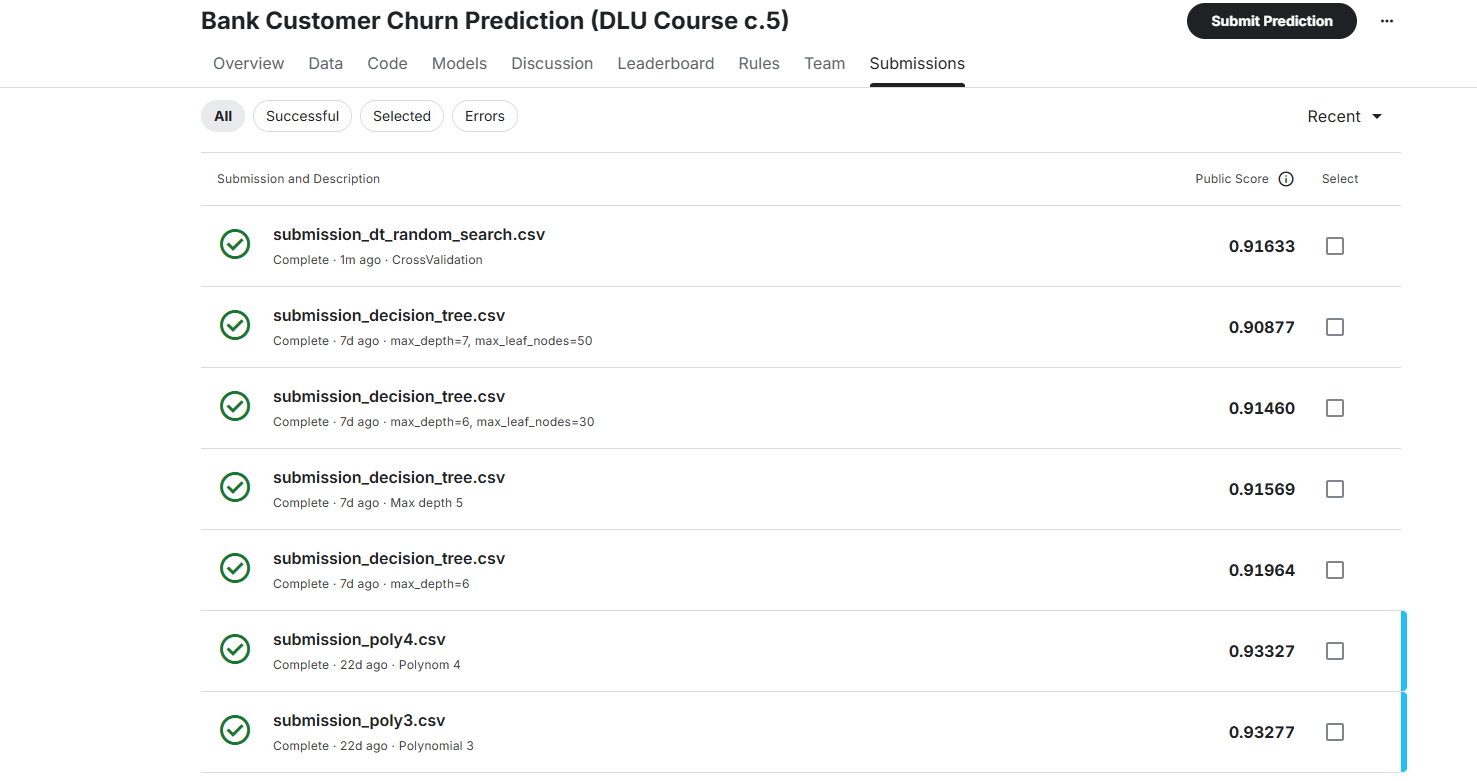